## Sprint 11
### Nivel 1

##### Ejercicio 1
Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4

In [16]:
! pip install mysql-connector-python


In [ ]:
! python -m pip install --upgrade pip

In [18]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt
from getpass import getpass

In [19]:
pwd = getpass("Inserta la contraseña: ")
cnx = mysql.connector.connect(user="root", password= pwd,
                              host="127.0.0.1",
                              database="transactions")
df_transactions = pd.read_sql("SELECT * FROM transactions", cnx)
df_companies    = pd.read_sql("SELECT * FROM companies", cnx)
df_users        = pd.read_sql("SELECT * FROM users", cnx)
df_credit_cards = pd.read_sql("SELECT * FROM credit_cards", cnx)
df_products     = pd.read_sql("SELECT * FROM products", cnx)
df_puente       = pd.read_sql("SELECT * FROM tabla_puente", cnx)

cnx.close()

df_companies
df_transactions



C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11052\979327750.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transactions = pd.read_sql("SELECT * FROM transactions", cnx)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11052\979327750.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_companies    = pd.read_sql("SELECT * FROM companies", cnx)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11052\979327750.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_users        = pd.read_sql("SELECT * FROM users", cnx)
C:\Users

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.5972,12.22180
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,72,2115,53.5489,-113.50300
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,18,3025,52.2084,5.69081
...,...,...,...,...,...,...,...,...,...,...
99995,FFF9E3CE-234E-408C-A8EF-F9CAD577224A,CcS-5010,b-2234,2022-12-17 20:57:55,247.39,0,"20, 42, 54, 46",429,52.5223,13.40490
99996,FFFB270D-F53A-4D5D-9666-E5307C53CC84,CcS-7655,b-2522,2024-05-13 03:42:03,349.13,0,"30, 87, 5, 66",3074,39.0271,-8.10523
99997,FFFC9E8D-27C7-4ADE-98F2-7533EF4DF126,CcS-5589,b-2302,2019-10-30 02:31:37,234.22,0,"16, 49",1008,59.3327,18.07530
99998,FFFCF76D-ECF0-4985-A2D0-B2A7B75998FC,CcS-5261,b-2250,2023-06-17 19:10:30,148.91,0,18,680,52.0635,4.30862


## Sprint 11
### Nivel 1

##### Ejercicio 2
2. Para cada elemento, crea una grafica adecuada según las variables especificadas. Interpreta los resultados según sus datos.

Recuerda: cuando selecciones las columnas, piensa siempre en el método que vas a utilizar e incluye las necesarias para la función de visualización que quieras utilizar .

- Una variable numérica.
- Dos variables numéricas.
- Una variable categórica.
- Una variable categórica y una numérica.
- Dos variables categóricas.
- Tres variables combinadas.
- Crea un Pairplot.

https://www.datacamp.com/es/tutorial/types-of-data-plots-and-how-to-create-them-in-python


### Una variable numerica--> histograma de frecuencias

<Axes: ylabel='Frequency'>

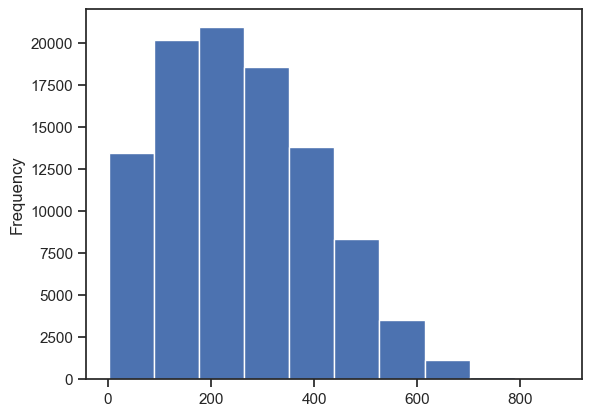

In [20]:
df_transactions["amount"].plot.hist(bins=10)

variable numerica en el eje x, en el eje y esta la frecuencia de esa variable,
se oberserva que la mayor frecuencia de las compras que se realiza son entre 100 y 200 €, es decir,
hay mayor frecuencia de compras con menor valor que las compras superiores a 300€
osea que son muy pocas las compras realizadas por valores muy altos

### Dos variables numericas:

relacion o distribucion --> grafica de dispersion
el peso de los productos en relacion al precio

<Axes: xlabel='weight', ylabel='price'>

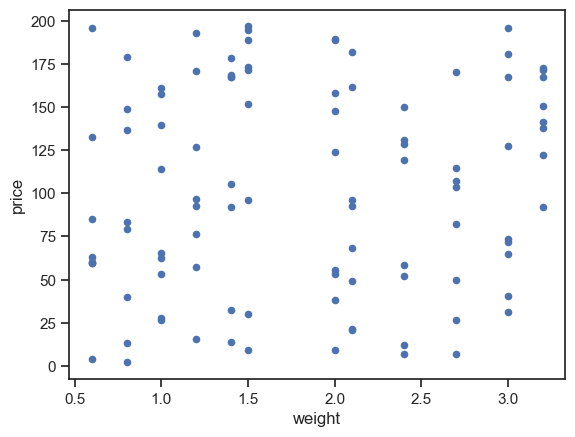

In [21]:
df_products.plot.scatter(x="weight", y="price")

el peso como variable indepedente no influye en el precio del producto?

en el grafico de dispersión se observa que no hay un patrón claro en la disposición de los puntos.
en caso de que el peso influyera en el precio se hubiera obtenido la concentracion de puntos en una linea crecinte.
conclusion: estas dos variables son independientes y el peso del producto no influye en el precio del mismo.

### Una variable categorica:

el numero de companies por pais
es el conteo de una variable 

<Axes: xlabel='country'>

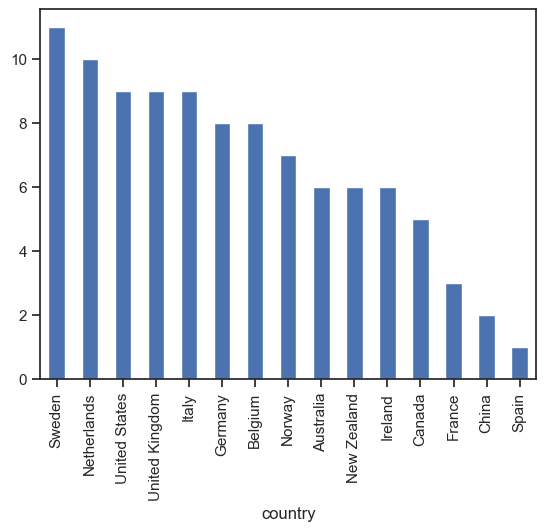

In [22]:
df_companies["country"].value_counts().plot.bar()

En este grafico se aprecia el numeroo de compañias en cada pais, se aprecia facilmente cuales son los paises con mas y con menos cantidad de empresas

### Una variable categórica y una numérica:

- media de ventas por pais
- merge entre transactions (amount).mean con companies (country) --> business_id=company_id

<Axes: xlabel='country'>

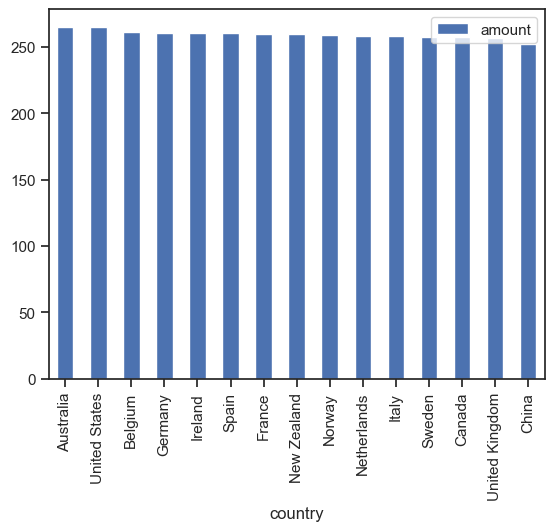

In [ ]:
transactions_companies=pd.merge(df_transactions, df_companies, left_on="business_id", right_on="company_id")
transactions_companies.groupby(["country"])[["amount"]].mean().sort_values(by="amount", ascending=False).plot.bar()

la media de ventas se ve similar entre los paises, se puede observar que china tiende a tener un poco menos de media.
Estados unidos y quizas australia sobresalen un poco mas. esto es de utilidad para conocer el comportamiento general de los mercados de cada pais y asi poder profundizar un poco mas en los paises que mejor y peor mercado tienen, por ejemplo

### Dos variables categóricas:
Cuantas transacciones son aceptadas y cuantas rechazadas (declined-transaction) por pais (companies)


<Axes: xlabel='country'>

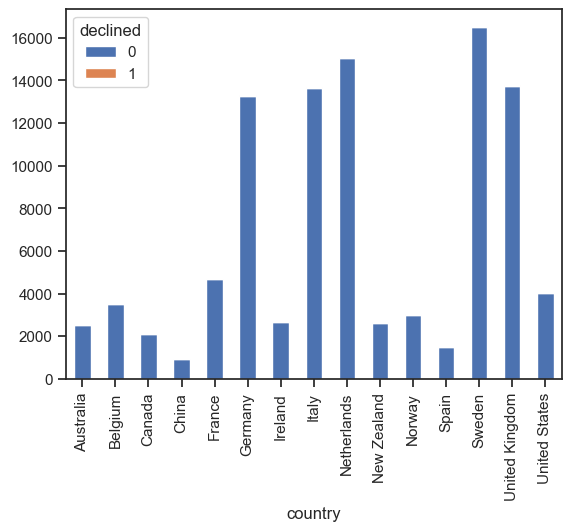

In [24]:
pd.crosstab(transactions_companies["declined"], transactions_companies["country"]).transpose().plot.bar(stacked=True)

Teniendo en cuenta que 0=aceptada y 1=rechazada, es super evidente de que la cantidad de transacciones que fueron rechazadas
es minima en comparacion a las aceptadas, puesto que las barras narajas que representan las rechazadas son casi imperceptibles

### Tres variables combinadas:
Vale para este punto voy a utilizar los resultados del grafico 4, en donde se analiza el amount (variable numerica) por pais (categorica).
- En este caso usaré el top 3 de paises con mayor ventas (variable categorica 1), de estos 3 paises se representaran la proporcion de transacciones aceptadas y denegadas (Variable categorica 2)

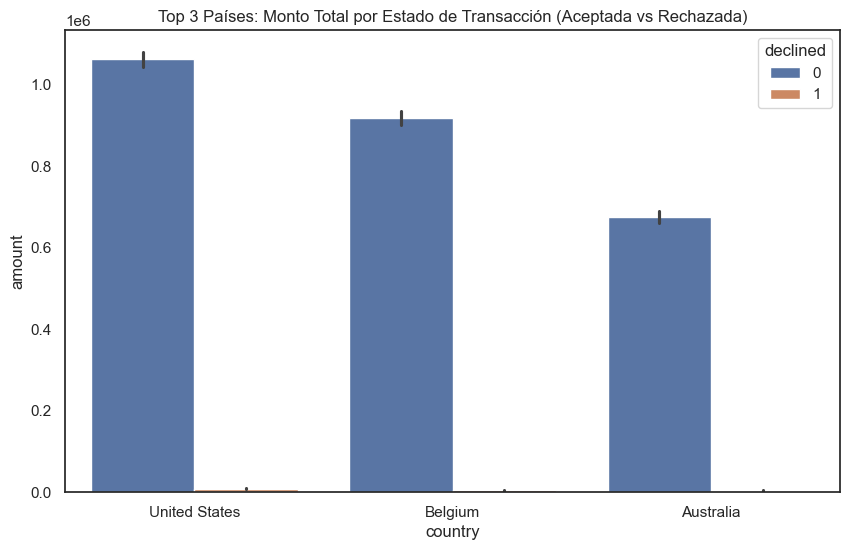

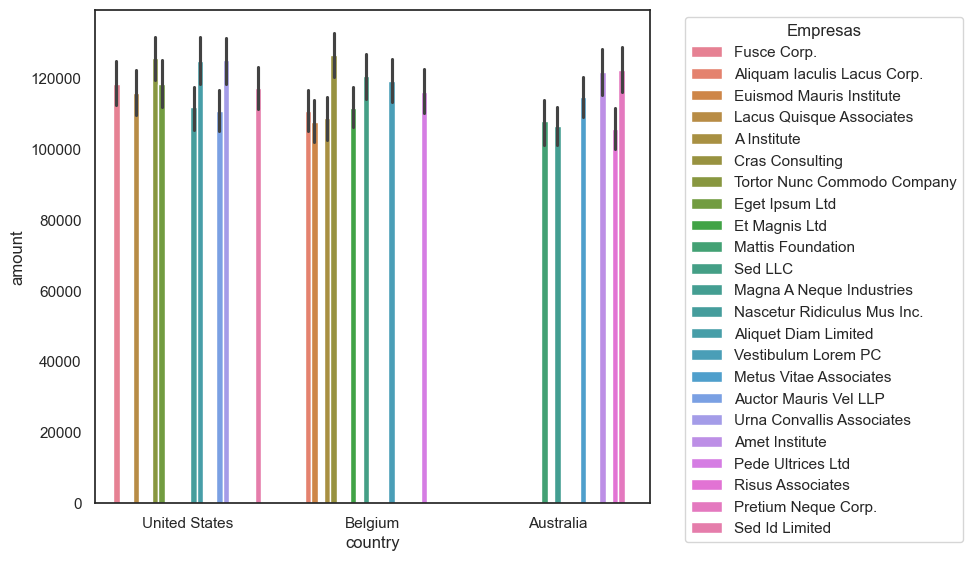

In [25]:
top_3_paises = transactions_companies.groupby("country")["amount"].mean().nlargest(3).index

df_top_3 = transactions_companies[transactions_companies['country'].isin(top_3_paises)]

sns.set_style("white")
plt.figure(figsize=(10, 6))

sns.barplot(data=df_top_3, x="country", y="amount", hue="declined", estimator=sum, errorbar=('ci', 95))

plt.title('Top 3 Países: Monto Total por Estado de Transacción (Aceptada vs Rechazada)')
plt.show()

sns.set_style("white")
plt.figure(figsize=(10, 6))

sns.barplot(data=df_top_3, x="country", y="amount", hue="company_name", estimator=sum, errorbar=('ci', 95))
plt.legend(title='Empresas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Bueno queria hacer la represetacion de las transacciones aceptadas y rechazadas pero como habiamos visto en el grafico anterior, las transacciones declinadas son tan minimas que en este caso son imperceptibles.

El segundo grafico lo hice para ver si tenia mejor pinta porque no me gusta que en el anteriorer no se vea absolutamente nada de las declinadas a pesar de que no se vean tambien es un resultado.

usé el companie_name como la otra variable categorica pero claro al ser tantas companies no me gusta como queda, es mas cuestion de estetica y de mi gusto que cualquier otra cosa. 

la en ambos graficos se usa el top 3 de paises con mayor promedio de amount y se evalua 1. la proporcion entre transacciones aceptadas/declinadas y 2. el amout de cada compañia de cada pais.

### Crea un Pairplot:

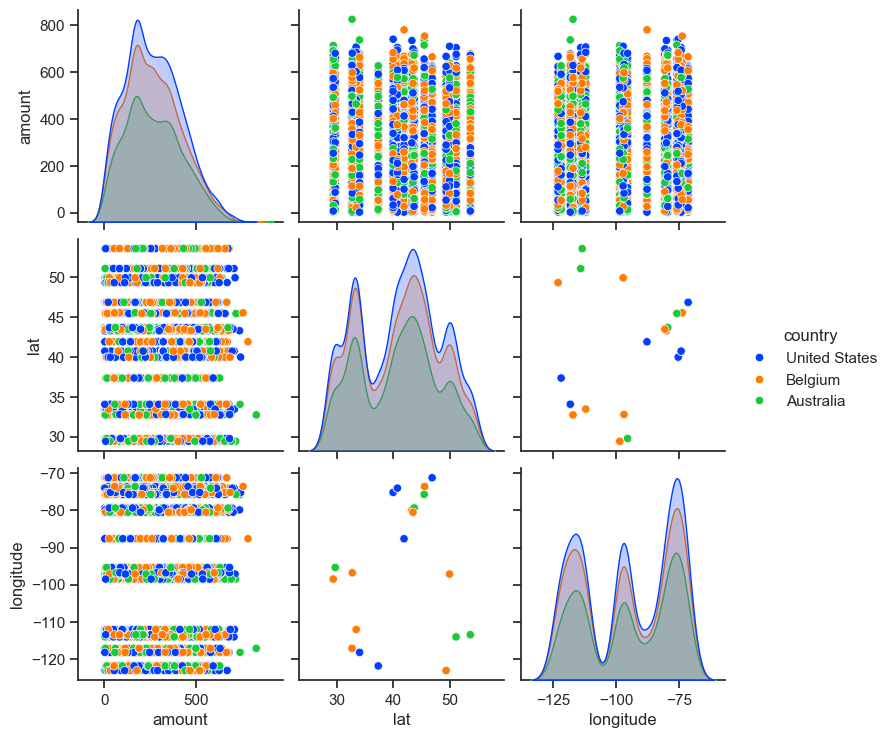

In [26]:
sns.set_theme(style="ticks")
columnas=["amount", "lat", "longitude"]

sns.pairplot(df_top_3[columnas + ["country"]], hue="country", palette="bright", diag_kind="kde")
plt.show()

interpretacion pairplot:
vale, en vista de que los graficos de la diagonal muestran la distribucion de cada variable individual y como se puede observar el patron de las montañas coincide en todas, por enden, el comportamiento de mercado coincide en los tres paises (amount) y bueno, la lat y longitude tambien coindiden los patrones y se ven claro los 3 picos que representan cada pais.

Vale en cuanto a los graficos de correlacion, se forman lineas tanto verticales como horizontales, lo cual indica relaciones lineales dejando claro que el gasto es homogeoneo en todas la ubicaciones, es decir que no cambia mucho entre un pais a otro (esto podria estar influenciado por haber elegido solo el top 3 de paises los cuales tenian comportamientos muy similares).

la dispersion de color estaria indicando que el pais no es determinante, si los colores estuvieran muy segregados entre si tal vez se referiria que la procedencia de los usuarios si genera un cambio importante.

## Sprint 11
### Nivel 2

##### Ejercicio 1
Representa la correlación de algunas variables e interpreta los resultados según tus datos.


In [27]:
df_corr = df_products[["price", "weight"]]

matriz = df_corr.corr(method="spearman").round(2)
matriz

,price,weight
price,1.00,0.11
weight,0.11,1.00


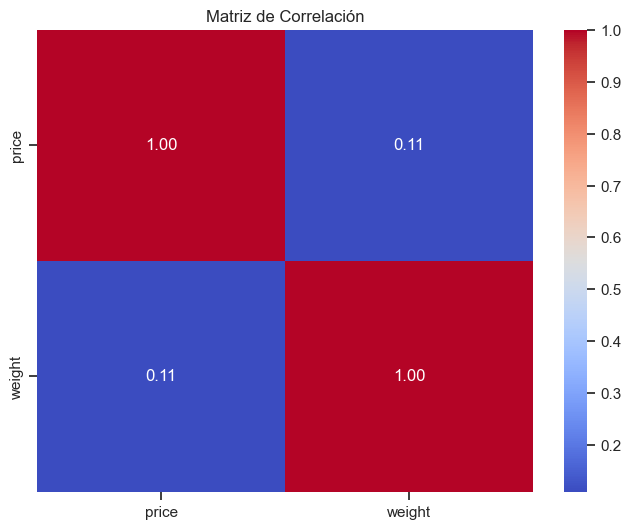

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

En la tabla de correlacion y en el heatmap podemos ver que hay un 0.11 de relacion entre el precio y el peso de los productos, aunque es una relacion positiva es muy debil como para afirmar que estan relacionadas, como ya lo habiamos determinado con el grafico de dispersion en ejercicios anteriores, estas dos variables no tienen relacion alguna 

### Nivel 2
##### Ejercicio 2
Implementa un Jointplot para explorar la relación entre dos variables e interpreta los resultados según tus datos.

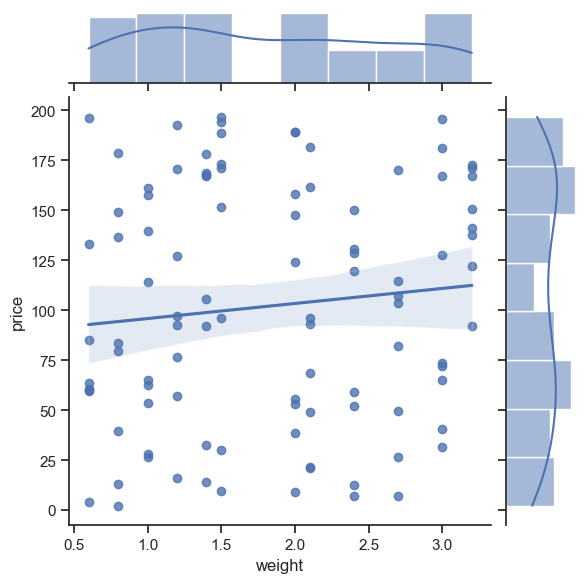

In [29]:
sns.jointplot(data=df_corr, x="weight", y="price", kind="reg")


Vale aqui nuevamente se observa la poca relacion entre estas dos variables, si estuvieran relacionadad la pendiente/inclinacion de la linea seria mucho mas pronunciada en funcion si es una relacion positiva o negativa y en este caso es casi totalmente horizontal, lo que indica la poca relacion entre estas dos variables. Tambien se evidencia en la dispercion de los puntos, aqui estan dispersos en su totalidad, en caso de existir relacion estaria ubicados mas cerca y al rededor de la linea y en caso de ser muy fuerte esa relacion sobre la misma linea.